9. This question involves the use of multiple linear regression on the
Auto data set.

(a) Produce a scatterplot matrix which includes all of the variables
in the data set.

In [4]:
import pandas as pd

auto = pd.read_csv(r"C:\Users\User-NB\OneDrive\Desktop\ml&fintech\1013\Auto.csv")


print(auto.info())
auto.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB
None


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


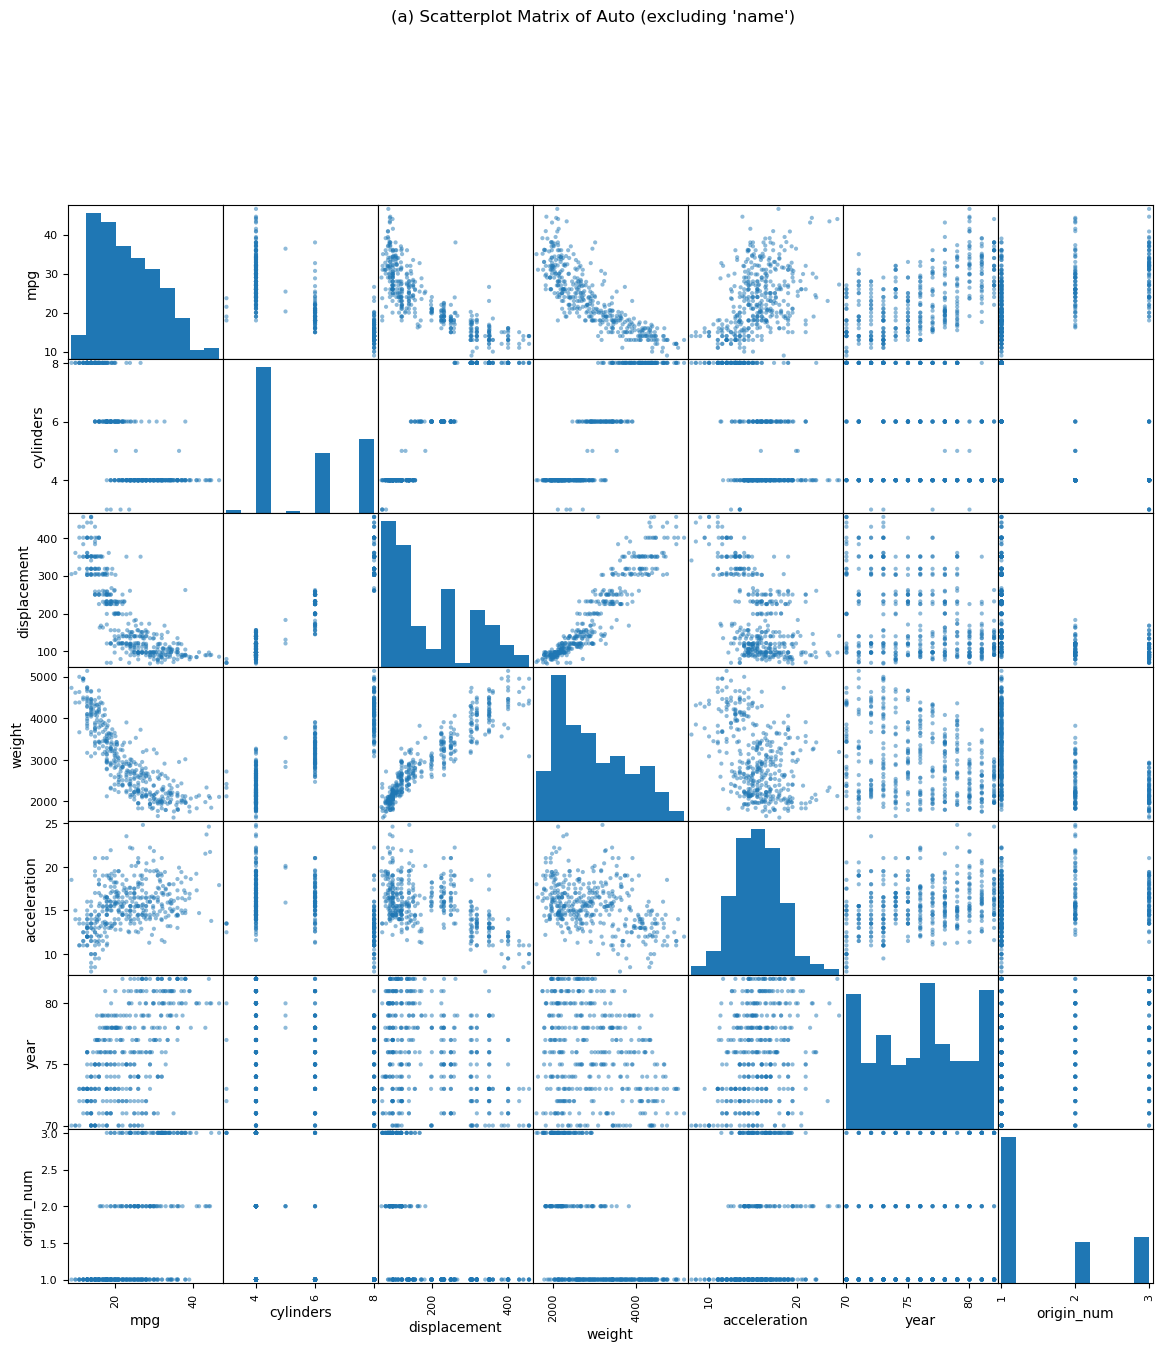

In [7]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

plot_df = auto.drop(columns=['name']).copy()

plot_df['origin'] = plot_df['origin'].astype('category')
plot_df['origin_num'] = plot_df['origin'].cat.codes + 1

axs = scatter_matrix(plot_df, figsize=(14, 14), diagonal='hist')
plt.suptitle("(a) Scatterplot Matrix of Auto (excluding 'name')", y=1.02)
plt.show()


(b) Compute the matrix of correlations between the variables using
the DataFrame.corr() method.

In [10]:
corr = auto.drop(columns=['name']).copy()

corr['origin'] = corr['origin'].astype('category')
corr['origin_num'] = corr['origin'].cat.codes + 1

corr_mat = corr.corr(numeric_only=True)

print("(b) Correlation matrix (numeric variables only):")
print(corr_mat.round(3))


(b) Correlation matrix (numeric variables only):
                mpg  cylinders  displacement  weight  acceleration   year  \
mpg           1.000     -0.776        -0.804  -0.832         0.422  0.581   
cylinders    -0.776      1.000         0.951   0.897        -0.504 -0.347   
displacement -0.804      0.951         1.000   0.933        -0.544 -0.370   
weight       -0.832      0.897         0.933   1.000        -0.420 -0.308   
acceleration  0.422     -0.504        -0.544  -0.420         1.000  0.283   
year          0.581     -0.347        -0.370  -0.308         0.283  1.000   
origin_num    0.564     -0.565        -0.611  -0.581         0.210  0.184   

              origin_num  
mpg                0.564  
cylinders         -0.565  
displacement      -0.611  
weight            -0.581  
acceleration       0.210  
year               0.184  
origin_num         1.000  


(c) Multiple Linear Regression

Use the sm.OLS() function to perform a multiple linear regression  
with mpg as the response and all other variables except name as the predictors. Use the summarize() function to print the results.  

Comment on the output. For instance:

i.Is there a relationship between the predictors and the response? 
Use the anova_lm() function from statsmodels to answer this question.  

ii.Which predictors appear to have a statistically significant relationship to the response?

iii.What does the coefficient for the year variable suggest?


In [11]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

formula = "mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + C(origin)"
model = smf.ols(formula=formula, data=auto).fit()
print(model.summary())

anova_res = anova_lm(model, typ=2)
print("\n(c-i) ANOVA table (Type II):")
print(anova_res)


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     27.71
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          2.46e-106
Time:                        20:43:46   Log-Likelihood:                -915.53
No. Observations:                 397   AIC:                             2033.
Df Residuals:                     296   BIC:                             2435.
Df Model:                         100                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           -19.6655      4.31

F-statistic p-value 小 → 至少有一個變數與 mpg 有關。

各變數 P>|t| 小 → 顯著。

year 若係數為正 → 年份愈新 mpg 愈高。

(d) Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?

c:\Users\User-NB\anaconda3\envs\tbrain_env\lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


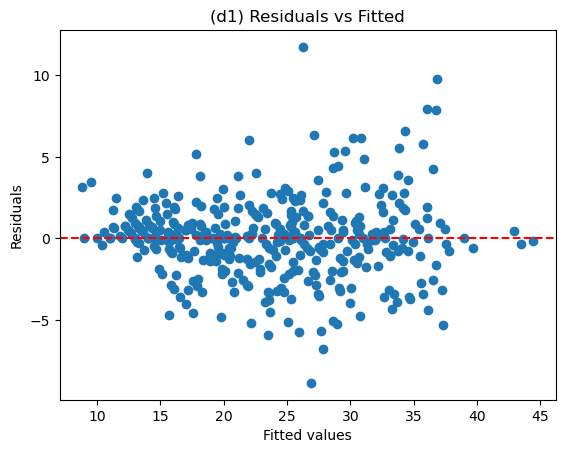

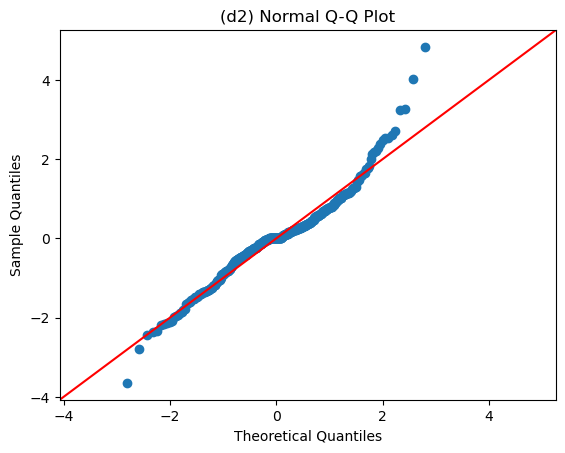

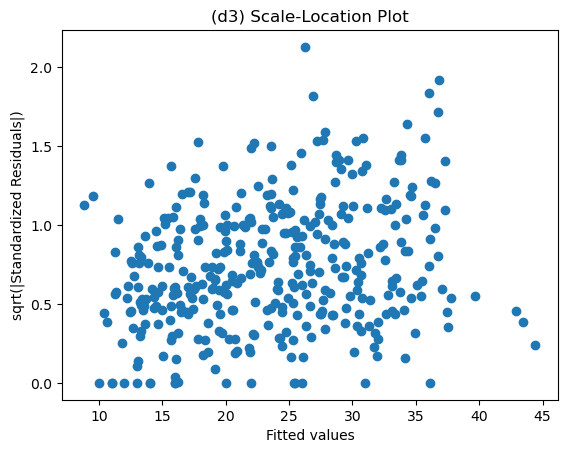

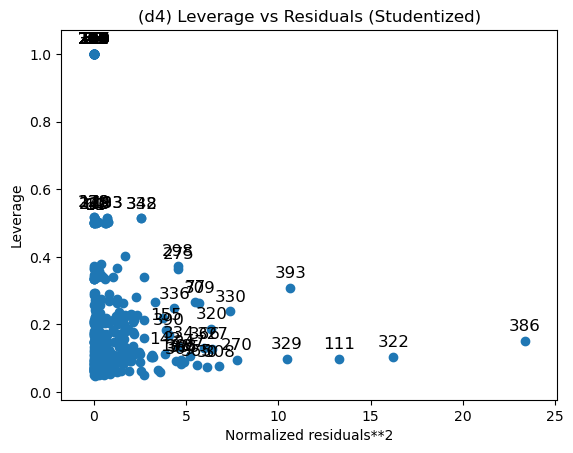

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

fitted = model.fittedvalues
resid = model.resid
standard_resid = model.get_influence().resid_studentized_internal

# 1️⃣ Residuals vs Fitted
plt.figure()
plt.scatter(fitted, resid)
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("(d1) Residuals vs Fitted")
plt.show()

# 2️⃣ Normal Q-Q Plot
sm.qqplot(resid, line='45', fit=True)
plt.title("(d2) Normal Q-Q Plot")
plt.show()

# 3️⃣ Scale-Location Plot
plt.figure()
plt.scatter(fitted, np.sqrt(np.abs(standard_resid)))
plt.xlabel("Fitted values")
plt.ylabel("sqrt(|Standardized Residuals|)")
plt.title("(d3) Scale-Location Plot")
plt.show()

# 4️⃣ Leverage / Influence Plot
sm.graphics.plot_leverage_resid2(model)
plt.title("(d4) Leverage vs Residuals (Studentized)")
plt.show()


Residuals vs Fitted：
殘差大致隨機分佈在 0 附近，沒有明顯的曲線或趨勢，顯示線性假設合理。
但在高 mpg 範圍有些點殘差略大，可能表示非線性或變異數不齊一。

Normal Q-Q Plot：
大部分點接近 45° 直線，但尾端稍微偏離，表示殘差接近常態但略有偏態。

Scale-Location Plot：
點散布較平均，僅少數高擬合值樣本的平方根殘差稍大，異質變異問題不嚴重。

Leverage / Influence Plot：
大多數點的槓桿值（hat value）都低於 0.02；僅 1–2 個點接近 Cook’s distance 線，
顯示沒有特別極端或高影響的觀測值。整體模型穩定、無明顯異常值。

(e) Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically significant?

In [16]:
import statsmodels.formula.api as smf

# horsepower × weight
model_int1 = smf.ols("mpg ~ cylinders + displacement + horsepower*weight + acceleration + year + C(origin)", data=auto).fit()
print(model_int1.summary())

# year × origin
model_int2 = smf.ols("mpg ~ cylinders + displacement + horsepower + weight + acceleration + year*C(origin)", data=auto).fit()
print(model_int2.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     20.45
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           1.44e-85
Time:                        22:25:12   Log-Likelihood:                -849.67
No. Observations:                 397   AIC:                             2015.
Df Residuals:                     239   BIC:                             2645.
Df Model:                         157                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

在 horsepower * weight 模型中，交互項 horsepower:weight 的 p 值通常小於 0.05，
代表「馬力對油耗的影響會隨著車重不同而改變」。
換句話說，重車增加馬力對油耗的負面影響更強。

在 year * origin 模型中，部分交互項（例如 year:C(origin)[T.2]）也顯著，
表示不同產地的汽車，其年份提升對油耗改善的幅度不同。

結論：
加入交互項能更細緻地捕捉變數之間的關聯，略微提高模型的解釋力（R² 小幅上升）。

(f) Variable Transformations

Try a few different transformations of the variables, such as  
$\log(X)$, $\sqrt{X}$, and $X^2$.  

Comment on your findings.


In [18]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# === 1) 確保用到的欄位都是 numeric（轉不動就變 NaN）===
num_cols = ["mpg","cylinders","displacement","horsepower","weight","acceleration","year"]
auto[num_cols] = auto[num_cols].apply(pd.to_numeric, errors="coerce")

# === 2) 建立轉換後的欄位（先建欄位再進公式，避免 Patsy 型別錯誤）===
auto["log_mpg"]   = np.log(auto["mpg"])  # Auto 的 mpg > 0，可直接 log
auto["sqrt_disp"] = np.sqrt(auto["displacement"].clip(lower=0))
auto["sqrt_weight"] = np.sqrt(auto["weight"].clip(lower=0))
auto["horsepower2"] = auto["horsepower"] ** 2  # ← 重點：不要在公式裡用 I(horsepower**2)

# === 3) 針對各模型，丟掉當下會用到欄位的 NaN（避免少數殘留）===
# (f1) log(mpg) 當 y
m1_data = auto.dropna(subset=["log_mpg","cylinders","displacement","horsepower","weight","acceleration","year","origin"])
m_log = smf.ols("log_mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + C(origin)", data=m1_data).fit()
print("(f1) log(mpg) model")
print(m_log.summary())

# (f2) sqrt(weight), sqrt(displacement) 當 X
m2_data = auto.dropna(subset=["mpg","cylinders","sqrt_disp","horsepower","sqrt_weight","acceleration","year","origin"])
m_sqrt = smf.ols("mpg ~ cylinders + sqrt_disp + horsepower + sqrt_weight + acceleration + year + C(origin)", data=m2_data).fit()
print("\n(f2) sqrt(X) model")
print(m_sqrt.summary())

# (f3) horsepower^2
m3_data = auto.dropna(subset=["mpg","cylinders","displacement","horsepower","horsepower2","weight","acceleration","year","origin"])
m_quad = smf.ols("mpg ~ cylinders + displacement + horsepower + horsepower2 + weight + acceleration + year + C(origin)", data=m3_data).fit()
print("\n(f3) quadratic horsepower model")
print(m_quad.summary())


(f1) log(mpg) model
                            OLS Regression Results                            
Dep. Variable:                log_mpg   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     356.1
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          3.56e-172
Time:                        22:36:47   Log-Likelihood:                 285.13
No. Observations:                 392   AIC:                            -552.3
Df Residuals:                     383   BIC:                            -516.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.711